# Data Manipulation

In [55]:
import os
import shutil 
shutil.copy(r"C:\Users\delloar1\Downloads\4342264.csv", os.getcwd())


'C:\\Users\\delloar1\\Data Science\\4342264.csv'

In [56]:
import pandas as pd

df = pd.read_csv("4342264.csv")
print(df.head())


       STATION                        NAME        DATE  DAPR  MDPR  PRCP  \
0  US1MDMG0071  SILVER SPRING 5.6 N, MD US  2026-01-10   NaN   NaN  0.04   
1  US1MDMG0071  SILVER SPRING 5.6 N, MD US  2026-01-11   NaN   NaN  1.03   
2  US1MDMG0071  SILVER SPRING 5.6 N, MD US  2026-01-16   NaN   NaN  0.00   
3  US1MDMG0071  SILVER SPRING 5.6 N, MD US  2026-01-17   NaN   NaN  0.00   
4  US1MDMG0071  SILVER SPRING 5.6 N, MD US  2026-01-18   NaN   NaN  0.19   

   SNOW  SNWD  TAVG  TMAX  TMIN  WT01  WT02  WT03  WT04  WT05  WT06  WT08  \
0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
1   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2   0.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
3   0.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
4   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   

   WT09  WT11  
0   NaN   NaN  
1   NaN   NaN  
2   NaN   NaN  
3   NaN   NaN  


In [57]:
print(df[["DATE", "TMAX", "TMIN", "PRCP"]].dropna(subset=["TMAX"]).head(10))
print(df.shape)

            DATE  TMAX  TMIN  PRCP
1880  2026-01-01  40.0  19.0  0.00
1881  2026-01-02  38.0  22.0  0.00
1882  2026-01-03  35.0  18.0  0.00
1883  2026-01-04  41.0  25.0  0.00
1884  2026-01-05  45.0  20.0  0.00
1885  2026-01-06  54.0  34.0  0.00
1886  2026-01-07  64.0  35.0  0.00
1887  2026-01-08  54.0  28.0  0.00
1888  2026-01-09  64.0  29.0  0.00
1889  2026-01-10  66.0  50.0  0.72
(28863, 20)


In [58]:
# Keeps only the meaningful columns
df_clean = df[["STATION","NAME", "DATE", "TMAX", "TMIN", "PRCP", "SNOW"]]
# Shows that it's working properly
print(df_clean.columns.tolist()) 

['STATION', 'NAME', 'DATE', 'TMAX', 'TMIN', 'PRCP', 'SNOW']


In [59]:
# Removes any rows where there is no data for max temp and min temp
df_clean = df_clean.dropna(subset=["TMAX","TMIN"])
# Shows the shape of the data and can see if your cleaning worked properly
print(df_clean.shape)

(4718, 7)


In [60]:
# coverts these from plain text dates to actual dates python can read and organize
df_clean["DATE"] = pd.to_datetime(df_clean["DATE"])
# Confirms what type of data "DATE" is
print(df_clean["DATE"].dtype)

datetime64[ns]


In [61]:
# Replaces all the blank values with zeros
df_clean["PRCP"] = df_clean["PRCP"].fillna(0)
df_clean["SNOW"] = df_clean["SNOW"].fillna(0)
# Shows the lines above worked properly
print(df_clean[["PRCP","SNOW"]].isnull().sum())

PRCP    0
SNOW    0
dtype: int64


In [62]:
print(df_clean.shape)

(4718, 7)


In [63]:
#That gives you three things at once; a sample of the actual rows,
# how many rows and columns you have, and a count of any remaining blanks
print(df_clean.head(10))
print()
print(df_clean.shape)
print()
print(df_clean.isnull().sum())

          STATION                                        NAME       DATE  \
1880  USW00093720  SALISBURY WICOMICO REGIONAL AIRPORT, MD US 2026-01-01   
1881  USW00093720  SALISBURY WICOMICO REGIONAL AIRPORT, MD US 2026-01-02   
1882  USW00093720  SALISBURY WICOMICO REGIONAL AIRPORT, MD US 2026-01-03   
1883  USW00093720  SALISBURY WICOMICO REGIONAL AIRPORT, MD US 2026-01-04   
1884  USW00093720  SALISBURY WICOMICO REGIONAL AIRPORT, MD US 2026-01-05   
1885  USW00093720  SALISBURY WICOMICO REGIONAL AIRPORT, MD US 2026-01-06   
1886  USW00093720  SALISBURY WICOMICO REGIONAL AIRPORT, MD US 2026-01-07   
1887  USW00093720  SALISBURY WICOMICO REGIONAL AIRPORT, MD US 2026-01-08   
1888  USW00093720  SALISBURY WICOMICO REGIONAL AIRPORT, MD US 2026-01-09   
1889  USW00093720  SALISBURY WICOMICO REGIONAL AIRPORT, MD US 2026-01-10   

      TMAX  TMIN  PRCP  SNOW  
1880  40.0  19.0  0.00   0.0  
1881  38.0  22.0  0.00   0.0  
1882  35.0  18.0  0.00   0.0  
1883  41.0  25.0  0.00   0.0  
1884  45

In [64]:
# The drop=True just means throw away the old index numbers instead of saving them as a column.
# Instead of starting at 1880, it will start at one now

df_clean = df_clean.reset_index(drop=True)
print(df_clean.head())

       STATION                                        NAME       DATE  TMAX  \
0  USW00093720  SALISBURY WICOMICO REGIONAL AIRPORT, MD US 2026-01-01  40.0   
1  USW00093720  SALISBURY WICOMICO REGIONAL AIRPORT, MD US 2026-01-02  38.0   
2  USW00093720  SALISBURY WICOMICO REGIONAL AIRPORT, MD US 2026-01-03  35.0   
3  USW00093720  SALISBURY WICOMICO REGIONAL AIRPORT, MD US 2026-01-04  41.0   
4  USW00093720  SALISBURY WICOMICO REGIONAL AIRPORT, MD US 2026-01-05  45.0   

   TMIN  PRCP  SNOW  
0  19.0   0.0   0.0  
1  22.0   0.0   0.0  
2  18.0   0.0   0.0  
3  25.0   0.0   0.0  
4  20.0   0.0   0.0  


### Finding what the hottest and coldest days of year has been so far (as of 6/24/26)

In [65]:
# df_clean["TMAX"].idxmax() finds the row number where TMAX is highest
# df_clean.loc[...] grabs that entire row so you can see the date, temp, and station

hottest = df_clean.loc[df_clean["TMAX"].idxmax()]
coldest = df_clean.loc[df_clean["TMIN"].idxmin()]

print("Hottest day: ", hottest["DATE"], "-", hottest["TMAX"], "F at", hottest["NAME"])
print("Coldest day: ", coldest["DATE"], "-", coldest["TMIN"], "F at", coldest["NAME"])












Hottest day:  2026-06-12 00:00:00 - 99.0 F at PATUXENT RIVER NAS, MD US
Coldest day:  2026-01-31 00:00:00 - -23.0 F at OAKLAND 1 SE, MD US


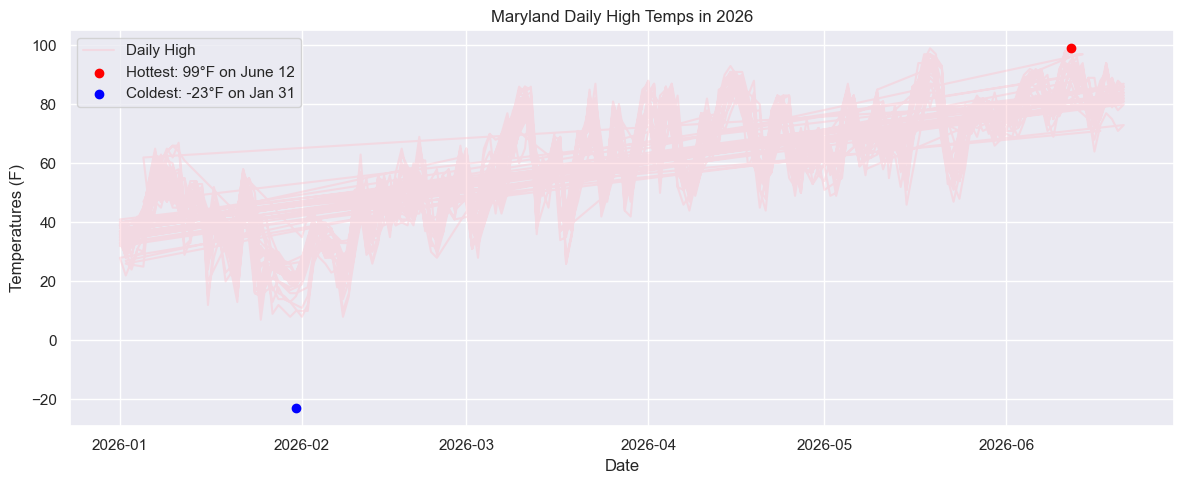

In [66]:
import matplotlib.pyplot as plt

# Plot every daily high this year
plt.figure(figsize=(12, 5))
plt.plot(df_clean["DATE"], df_clean["TMAX"], color = "pink", alpha = 0.4, label= "Daily High")

# put a dot on the hottest day
plt.scatter(hottest["DATE"], hottest["TMAX"], color='red', zorder = 5, label = f'Hottest: 99°F on June 12')

# put a dot on the coldest day
plt.scatter(coldest["DATE"], coldest["TMIN"], color="blue", zorder=5, label=f'Coldest: -23°F on Jan 31')

plt.title("Maryland Daily High Temps in 2026")
plt.xlabel("Date")
plt.ylabel("Temperatures (F)")
plt.legend()
plt.tight_layout()
plt.show()

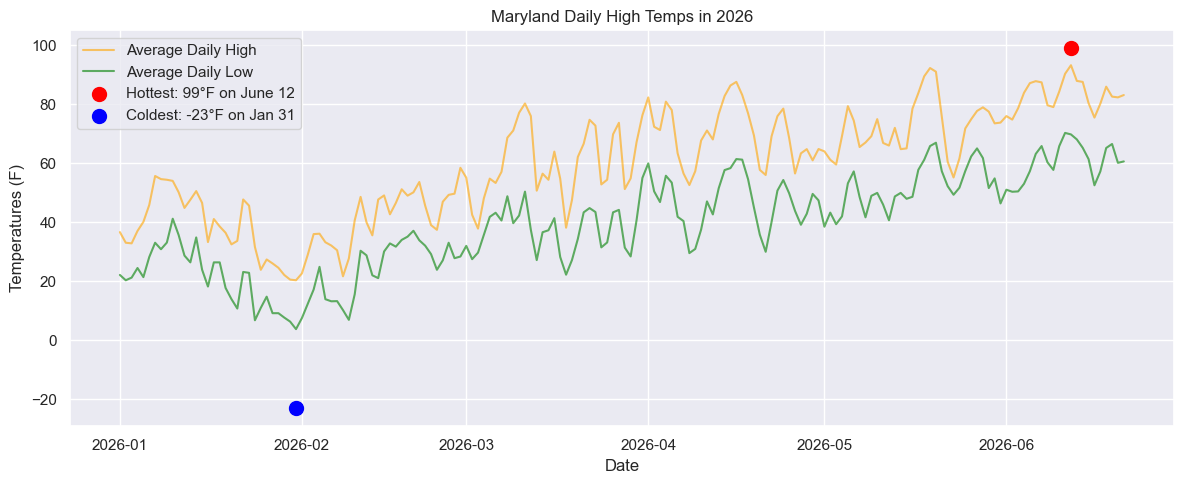

In [67]:
# Trying to make it better
import matplotlib.pyplot as plt

# Average all the weather stations into one to make it cleaner
df_avg = df_clean.groupby("DATE")[["TMAX","TMIN"]].mean().reset_index()

# Plot every daily high this year
plt.figure(figsize=(12, 5))
plt.plot(df_avg["DATE"], df_avg["TMAX"], color = "orange", alpha = 0.6, label= "Average Daily High")
plt.plot(df_avg["DATE"], df_avg["TMIN"], color = "green", alpha = 0.6, label= "Average Daily Low")

# put a dot on the hottest day
plt.scatter(hottest["DATE"], hottest["TMAX"], color='red', zorder = 5, s=100, label = f'Hottest: 99°F on June 12')

# put a dot on the coldest day
plt.scatter(coldest["DATE"], coldest["TMIN"], color="blue", zorder=5, s=100, label=f'Coldest: -23°F on Jan 31')

plt.title("Maryland Daily High Temps in 2026")
plt.xlabel("Date")
plt.ylabel("Temperatures (F)")
plt.legend()
plt.tight_layout()
plt.show()

### Use a different program to make it even cleaner

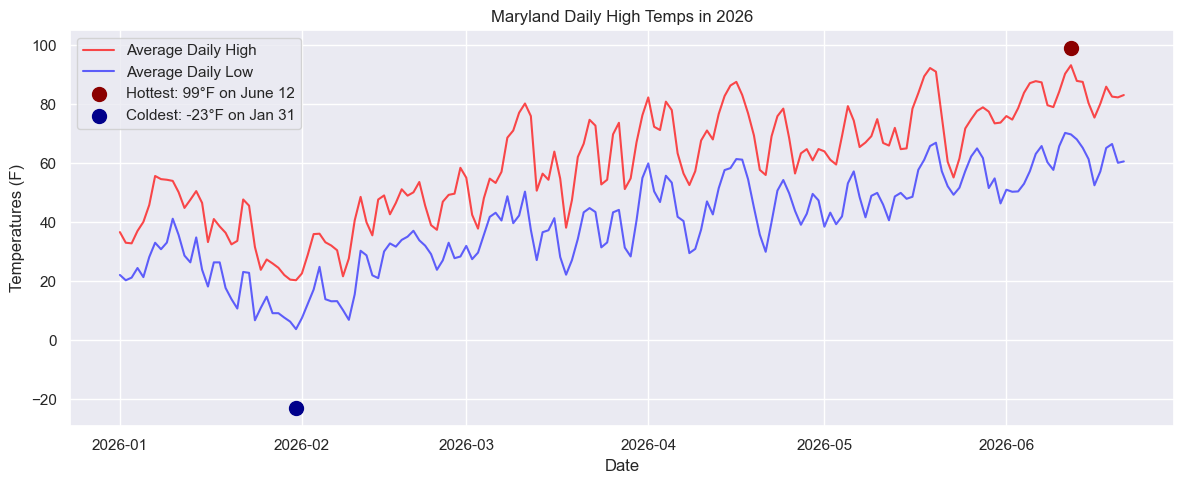

In [68]:
import seaborn as sns
#Sets the style
sns.set_theme(style="darkgrid")

plt.figure(figsize=(12,5))

# Same type of code from above with slight changes

sns.lineplot(data = df_avg, x="DATE", y = "TMAX", color = "red", alpha = 0.7, label= "Average Daily High")
sns.lineplot(data = df_avg, x="DATE", y = "TMIN", color = "blue", alpha = 0.6, label= "Average Daily Low")

# put a dot on the hottest day
plt.scatter(hottest["DATE"], hottest["TMAX"], color='darkred', zorder = 5, s=100, label = f'Hottest: 99°F on June 12')

# put a dot on the coldest day
plt.scatter(coldest["DATE"], coldest["TMIN"], color="darkblue", zorder=5, s=100, label=f'Coldest: -23°F on Jan 31')

plt.title("Maryland Daily High Temps in 2026")
plt.xlabel("Date")
plt.ylabel("Temperatures (F)")
plt.legend()
plt.tight_layout()
plt.show()

### Look into trends within the temps

In [69]:
from scipy import stats 

# Converts dates to numbers in order to do math on them for scipy
df_avg["DATE_NUM"] = (df_avg["DATE"] - df_avg["DATE"].min()).dt.days

# Run a linear regression model

result = stats.linregress(df_avg["DATE_NUM"], df_avg["TMAX"])
slope = result.slope
intercept = result.intercept
r_value = result.rvalue
p_value = result.pvalue

# The rise in temperature per day
print(f" Slope: {slope:.3f} degrees per day")

# How well the trend line will fit
print(f" R-squared: {r_value**2:.3f}")

#tells you if the trend is statistically real or just random noise — below 0.05 means it's real
print(f" P-value: {p_value: .5f}")


 Slope: 0.309 degrees per day
 R-squared: 0.681
 P-value:  0.00000


#### Take these numbers and plot them

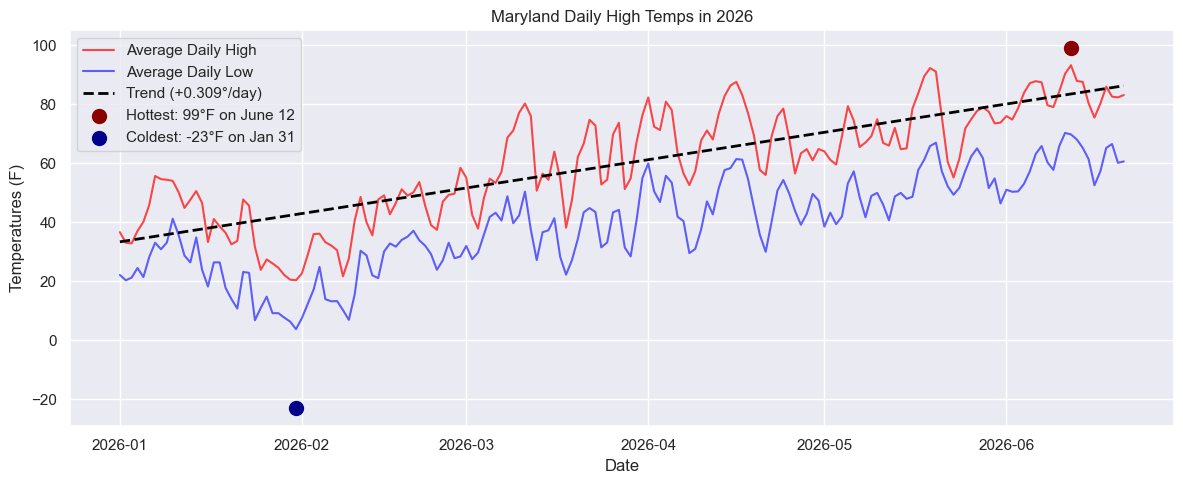

In [70]:
import seaborn as sns

df_avg["TREND"] = slope * df_avg["DATE_NUM"] + intercept

#Sets the style
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12,5))

# Same type of code from above with slight changes

sns.lineplot(data = df_avg, x="DATE", y = "TMAX", color = "red", alpha = 0.7, label= "Average Daily High")
sns.lineplot(data = df_avg, x="DATE", y = "TMIN", color = "blue", alpha = 0.6, label= "Average Daily Low")

#PLot the trend line
plt.plot(df_avg["DATE"], df_avg["TREND"], color = "black", linewidth=2, linestyle="--", label=f"Trend (+0.309°/day)")

# put a dot on the hottest day
plt.scatter(hottest["DATE"], hottest["TMAX"], color='darkred', zorder = 5, s=100, label = f'Hottest: 99°F on June 12')

# put a dot on the coldest day
plt.scatter(coldest["DATE"], coldest["TMIN"], color="darkblue", zorder=5, s=100, label=f'Coldest: -23°F on Jan 31')

plt.title("Maryland Daily High Temps in 2026")
plt.xlabel("Date")
plt.ylabel("Temperatures (F)")
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Create a "tomorrow's high" column by shifting TMAX back one day
df_avg["TMAX_TOMORROW"] = df_avg["TMAX"].shift(-1)

# Drop the last row since it has no tomorrow
df_model = df_avg.dropna(subset=["TMAX_TOMORROW"])

# Features we're using to predict
X = df_model[["TMAX", "TMIN", "DATE_NUM"]]

# What we're trying to predict
y = df_model["TMAX_TOMORROW"]

# Train the model
model = LinearRegression()
model.fit(X, y)

print(f"Model Score: {model.score(X, y):.3f}")

Model Score: 0.867


In [72]:
print(df_avg["DATE"].max())

2026-06-21 00:00:00


In [73]:
# Today's values to predict tomorrow
today_tmax = df_avg["TMAX"].iloc[-1]
today_tmin = df_avg["TMIN"].iloc[-1]
today_date_num = df_avg["DATE_NUM"].iloc[-1]

# Make the prediction
prediction = model.predict(pd.DataFrame([[today_tmax, today_tmin, today_date_num]], columns=["TMAX", "TMIN", "DATE_NUM"]))

print(f"Today's High: {today_tmax:.1f}F")
print(f"Today's Low: {today_tmin:.1f}F")
print(f"Predicted High for Tomorrow: {prediction[0]:.1f}F")

Today's High: 83.2F
Today's Low: 60.7F
Predicted High for Tomorrow: 84.2F


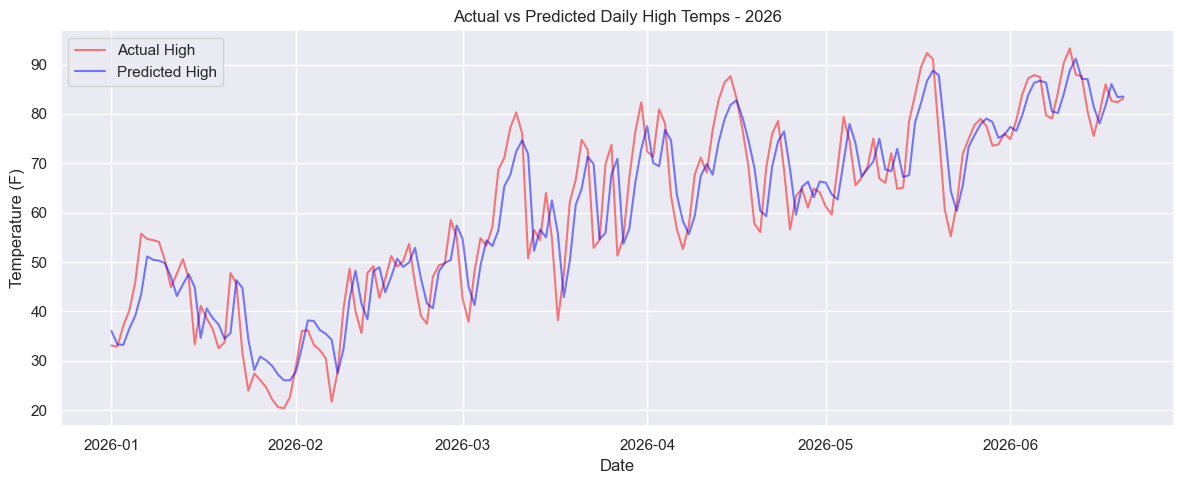

In [77]:
df_model["TMAX_PREDICTED"] = model.predict(X)

sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 5))

sns.lineplot(data=df_model, x="DATE", y="TMAX_TOMORROW", color="red", alpha=0.5, label="Actual High")
sns.lineplot(data=df_model, x="DATE", y="TMAX_PREDICTED", color="blue", alpha=0.5, label="Predicted High")

plt.title("Actual vs Predicted Daily High Temps - 2026")
plt.xlabel("Date")
plt.ylabel("Temperature (F)")
plt.legend()
plt.tight_layout()
plt.show()

## Observations:
#### The model stuggles in the winter months but becomes much better as it warms up outside. 
#### The weather is much more unpredictable in the winter months which is why the model seems to struggle at those times.
#### The model does a good job at capturing the steady increase in temperature from winter to summer.